### Imports

In [1]:
import os
import time
import copy
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# A biblioteca TIMM possui os modelos Vision Mamba
import timm 

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")
print(f"Versão do timm: {timm.__version__}")

Dispositivo em uso: cuda:0
Versão do timm: 1.0.27


### Transformações e Pré-processamento de dados

In [2]:
base_dir = '../../chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_base_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['val']) 
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['val'])

targets = full_train_dataset.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=42
)

train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(val_base_dataset, val_idx)

batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_subset), 'val': len(val_subset)}
class_names = full_train_dataset.classes


### Construção do Modelo Mamba

In [ ]:
# Cálculo de pesos para classes desbalanceadas
train_classes = [targets[i] for i in train_idx]
class_counts = Counter(train_classes)
num_classes = len(class_names)
total_samples = len(train_classes)

class_weights_list = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights = torch.FloatTensor(class_weights_list).to(device)

def create_mamba_model(num_classes=3, freeze_features=True):
    # Procurar modelos Mamba/SSM disponíveis na versão atual do timm
    all_models = timm.list_models()
    # Filtra modelos que contenham mamba, vim ou vssm no nome
    ssm_models = [m for m in all_models if 'mamba' in m or 'vim' in m or 'vssm' in m]
    
    if not ssm_models:
        raise RuntimeError(
            "Nenhum modelo Mamba/Vim/VSSM encontrado no TIMM. "
            "Por favor, atualize o timm rodando no terminal: pip install --upgrade timm"
        )
    
    # Preferência por 'mambaout_base' ou 'mambaout_small' (não requerem compilação CUDA complexa)
    model_name = next((m for m in ssm_models if 'mambaout_small' in m), None)
    if not model_name:
        model_name = ssm_models[0] # Pega o primeiro disponível se não achar o mambaout
        
    print(f"Modelo SSM encontrado e selecionado: {model_name}")
    
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    if freeze_features:
        # Congela todos os pesos
        for param in model.parameters():
            param.requires_grad = False
        
        # Descongela apenas a cabeça de classificação do modelo TIMM
        for param in model.get_classifier().parameters():
            param.requires_grad = True
            
    return model

model_mamba = create_mamba_model(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_mamba.get_classifier().parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

### Loop de Treinamento

In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Época {epoch+1}/{num_epochs} \n' + '-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            progress_bar = tqdm(dataloaders[phase], desc=f"{phase.capitalize()} Epoch {epoch+1}", leave=False)

            for inputs, labels in progress_bar:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Treinamento concluído em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Melhor Acurácia de Validação: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

### Execução do Treino

In [5]:
print("A iniciar o treino do Mamba...")
model_mamba = train_model(model_mamba, criterion, optimizer, scheduler, num_epochs=10)
torch.save(model_mamba.state_dict(), 'mamba_pneumonia_best.pth')
print("Pesos do Mamba guardados.")

A iniciar o treino do Mamba...
Época 1/10 
----------


Train Epoch 1:   0%|          | 0/131 [00:07<?, ?it/s]

Train - Loss: 0.6768 Acc: 0.7027


Val Epoch 1:   0%|          | 0/33 [00:07<?, ?it/s]

Val - Loss: 0.6008 Acc: 0.7450

Época 2/10 
----------


...

Val - Loss: 0.5143 Acc: 0.7689

Época 10/10 
----------


Train Epoch 10:   0%|          | 0/131 [00:07<?, ?it/s]

Train - Loss: 0.4701 Acc: 0.7847


Val Epoch 10:   0%|          | 0/33 [00:07<?, ?it/s]

Val - Loss: 0.4995 Acc: 0.7593

Treinamento concluído em 21m 24s
Melhor Acurácia de Validação: 0.7889
Pesos do Mamba guardados.


### Avaliação Visual

A testar:   0%|          | 0/20 [00:00<?, ?it/s]


Relatório de Classificação:

                     precision    recall  f1-score   support

             NORMAL       0.88      0.67      0.76       234
PNEUMONIA_BACTERIAL       0.78      0.90      0.84       242
    PNEUMONIA_VIRAL       0.68      0.75      0.71       148

           accuracy                           0.78       624
          macro avg       0.78      0.78      0.77       624
       weighted avg       0.79      0.78      0.78       624



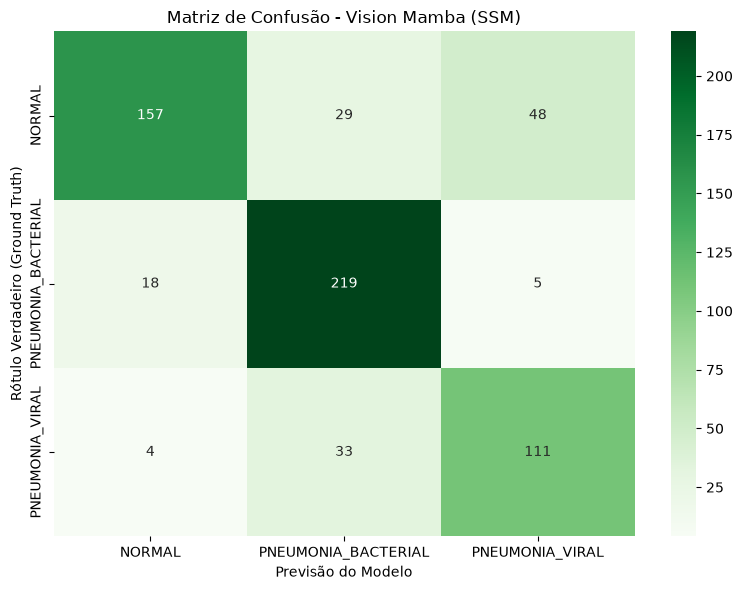

In [6]:
model_mamba.load_state_dict(torch.load('mamba_pneumonia_best.pth'))
model_mamba.to(device)

def evaluate_and_plot(model, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="A testar", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    print("\nRelatório de Classificação:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusão - Vision Mamba (SSM)')
    plt.ylabel('Rótulo Verdadeiro (Ground Truth)')
    plt.xlabel('Previsão do Modelo')
    plt.tight_layout()
    plt.show()

evaluate_and_plot(model_mamba, test_loader, class_names)